In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('dataset/train.csv')
# df = df[0:7000][:]
print(df.shape)
df.head()

(193573, 11)


,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       193573 non-null  int64  
 1   carat    193573 non-null  float64
 2   cut      193573 non-null  object 
 3   color    193573 non-null  object 
 4   clarity  193573 non-null  object 
 5   depth    193573 non-null  float64
 6   table    193573 non-null  float64
 7   x        193573 non-null  float64
 8   y        193573 non-null  float64
 9   z        193573 non-null  float64
 10  price    193573 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 16.2+ MB


In [4]:
df.describe()

,id,carat,depth,table,x,y,z,price
count,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000,193573.000000
mean,96786.000000,0.790688,61.820574,57.227675,5.715312,5.720094,3.534246,3969.155414
std,55879.856166,0.462688,1.081704,1.918844,1.109422,1.102333,0.688922,4034.374138
min,0.000000,0.200000,52.100000,49.000000,0.000000,0.000000,0.000000,326.000000
25%,48393.000000,0.400000,61.300000,56.000000,4.700000,4.710000,2.900000,951.000000
50%,96786.000000,0.700000,61.900000,57.000000,5.700000,5.720000,3.530000,2401.000000
75%,145179.000000,1.030000,62.400000,58.000000,6.510000,6.510000,4.030000,5408.000000
max,193572.000000,3.500000,71.600000,79.000000,9.650000,10.010000,31.300000,18818.000000


In [5]:
df.columns

Index(['id', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y',
       'z', 'price'],
      dtype='object')

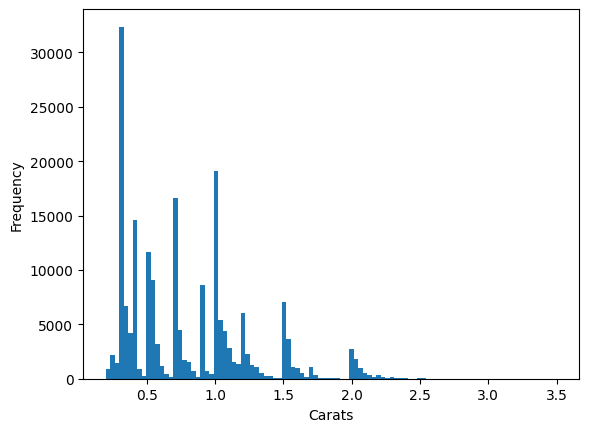

In [6]:
plt.hist(df['carat'],bins=100)
plt.xlabel('Carats')
plt.ylabel('Frequency')
plt.show()

In [7]:
df['color'].value_counts()

color
G    44391
E    35869
F    34258
H    30799
D    24286
I    17514
J     6456
Name: count, dtype: int64

In [8]:
color_map = {
    'D': '#A9CCE3',
    'E': '#AED6F1',
    'F': '#85C1E9',
    'G': '#5DADE2',
    'H': '#3498DB',
    'I': '#2E86C1',
    'J': '#1F618D'
}


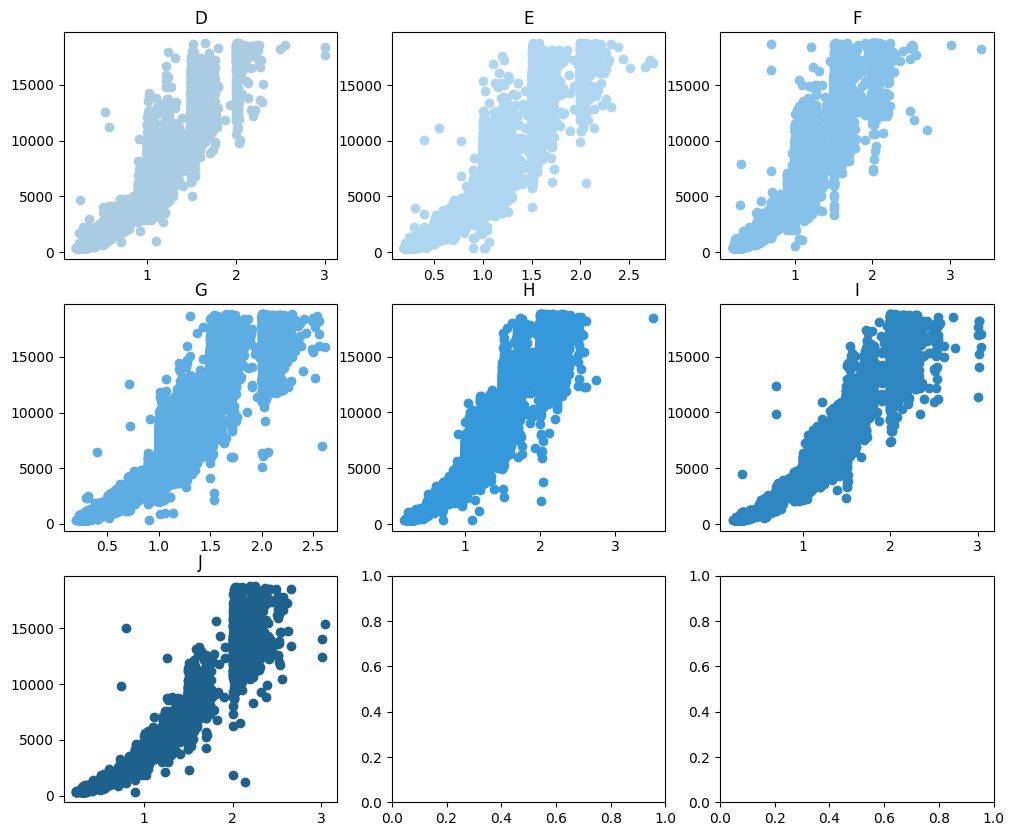

In [9]:
fig,axes = plt.subplots(3,3,figsize=(12,10))
x = 0
y = 0
for color in color_map:
    axes[y,x].scatter(df[df['color']==color]['carat'],df[df['color']==color]['price'],c=color_map[color])
    axes[y,x].set_title(color)
    x += 1
    if x==3:
        y += 1
        x = 0
plt.show()

Color is thus not such an important factor for the Price, it is linearly dependent with Carats

In [10]:
df["Volume"] = df["x"]*df["y"]*df["z"]
df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price,Volume
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619,242.465405
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387,330.508360
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772,114.112950
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666,52.345818
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453,277.692705


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 12 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       193573 non-null  int64  
 1   carat    193573 non-null  float64
 2   cut      193573 non-null  object 
 3   color    193573 non-null  object 
 4   clarity  193573 non-null  object 
 5   depth    193573 non-null  float64
 6   table    193573 non-null  float64
 7   x        193573 non-null  float64
 8   y        193573 non-null  float64
 9   z        193573 non-null  float64
 10  price    193573 non-null  int64  
 11  Volume   193573 non-null  float64
dtypes: float64(7), int64(2), object(3)
memory usage: 17.7+ MB


<Axes: >

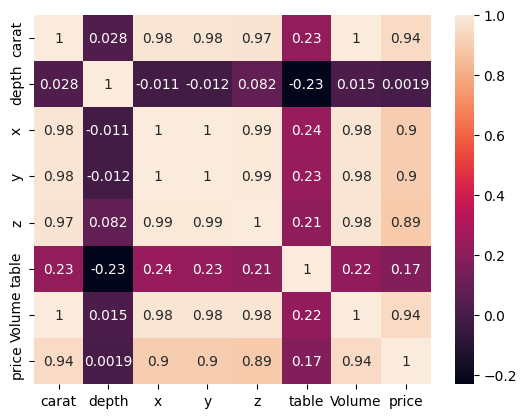

In [12]:
import seaborn as sns
L = ['carat','depth','x','y','z','table','Volume','price']
df_subset = df[L]
corr = df_subset.corr(method='pearson')
sns.heatmap(corr,annot=True)

In [13]:
df.drop(['depth'],axis=1,inplace=True)

In [13]:
df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price,Volume
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619,242.465405
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387,330.508360
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772,114.112950
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666,52.345818
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453,277.692705


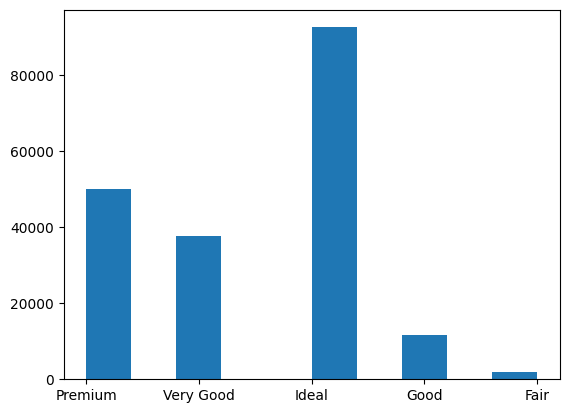

In [14]:
plt.hist(df['cut'])
plt.show()

In [15]:
df['cut'].value_counts()

cut
Ideal        92454
Premium      49910
Very Good    37566
Good         11622
Fair          2021
Name: count, dtype: int64

In [16]:
df['clarity'].value_counts()

clarity
SI1     53272
VS2     48027
VS1     30669
SI2     30484
VVS2    15762
VVS1    10628
IF       4219
I1        512
Name: count, dtype: int64

In [17]:
df.columns

Index(['id', 'carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y',
       'z', 'price', 'Volume'],
      dtype='object')

In [18]:
L2 = df.columns
L2 = list(L2)
L2.remove('price')
X = df[L2]
Y = df['price']

In [36]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [37]:
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

clarity_categories = [['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']]
cut_order = [['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']]

pipeline = Pipeline([
    ('s1',SimpleImputer(strategy='most_frequent')),
    ('s2',OrdinalEncoder(categories=clarity_categories)),
])

pipeline2 = Pipeline([
    ('s1',SimpleImputer(strategy='most_frequent')),
    ('s2',OrdinalEncoder(categories=cut_order)),
])

pipeline3 = Pipeline([
    ('s1',SimpleImputer(strategy='mean')),
])

ct = ColumnTransformer(
    transformers=[
        ('clar',pipeline,['clarity']),
        ('cut',pipeline2,['cut']),
        ('others',pipeline3,['carat','table','x','y','z','Volume'])
    ],remainder='passthrough'
)

ct.fit(X_train)
ct.set_output(transform="pandas")
# Index(['id', 'carat', 'cut', 'color', 'clarity', 'table', 'x', 'y', 'z',
#        'price', 'Volume'],
#       dtype='object')

/home/om/Documents/Codes/venv/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('clar',
                                 Pipeline(steps=[('s1',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('s2',
                                                  OrdinalEncoder(categories=[['I1',
                                                                              'SI2',
                                                                              'SI1',
                                                                              'VS2',
                                                                              'VS1',
                                                                              'VVS2',
                                                                              'VVS1',
                                                                              'IF']]))]),
                                 ['clarity']),
                                ('cut',
                                 Pipeline(steps=[('s1',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('s2',
                                                  OrdinalEncoder(categories=[['Fair',
                                                                              'Good',
                                                                              'Very '
                                                                              'Good',
                                                                              'Premium',
                                                                              'Ideal']]))]),
                                 ['cut']),
                                ('others',
                                 Pipeline(steps=[('s1', SimpleImputer())]),
                                 ['carat', 'table', 'x', 'y', 'z', 'Volume'])])

In [59]:
from sklearn.neural_network import MLPRegressor
model = MLPRegressor()
model.fit(X_train,Y_train)
Y_pred = model.predict(X_test)
print(root_mean_squared_error(Y_test,Y_pred))

921.8446585911537


/home/om/Documents/Codes/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [38]:
X_train = ct.transform(X_train)
X_test = ct.transform(X_test)

/home/om/Documents/Codes/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but OrdinalEncoder was fitted without feature names
  warnings.warn(
/home/om/Documents/Codes/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but OrdinalEncoder was fitted without feature names
  warnings.warn(
/home/om/Documents/Codes/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but OrdinalEncoder was fitted without feature names
  warnings.warn(
/home/om/Documents/Codes/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but OrdinalEncoder was fitted without feature names
  warnings.warn(


In [40]:
X_train.drop(['remainder__color'],axis=1,inplace=True)
X_test.drop(['remainder__color'],axis=1,inplace=True)
sc = StandardScaler()
sc.fit(X_train)
X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

In [50]:
import joblib
joblib.dump(ct,'column_transformer.pkl')
import joblib
joblib.dump(sc,'Standard_Scaler.pkl')

['Standard_Scaler.pkl']

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge,LinearRegression,SGDRegressor

In [42]:
params = {
    'alpha':[0,0.1,0.2,0.3,1],
    'fit_intercept':[True,False],
    'tol':[1e-0,1e-1,1e-2,1e-3]
}
gc = GridSearchCV(Ridge(),param_grid=params,cv=4,scoring='neg_mean_squared_error')

In [43]:
gc.fit(X_train,Y_train)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid={'alpha': [0, 0.1, 0.2, 0.3, 1],
                         'fit_intercept': [True, False],
                         'tol': [1.0, 0.1, 0.01, 0.001]},
             scoring='neg_mean_squared_error')

In [44]:
gc.score(X_test,Y_test)

-1172847.11854733

In [45]:
gc.score(X_train,Y_train)

-1194495.9575399503

In [48]:
print(Y_test.head())
print(pd.DataFrame(gc.predict(X_test)).head())

14868      1355
165613    14691
96727       844
145593      707
118689     5797
Name: price, dtype: int64
              0
0   1011.197625
1  14676.809995
2   1216.676238
3   1412.262324
4   6931.341735


In [49]:
from sklearn.metrics import root_mean_squared_error
print(root_mean_squared_error(Y_test,gc.predict(X_test)))

1082.9806639766612


In [51]:
gc.best_params_

{'alpha': 1, 'fit_intercept': True, 'tol': 1.0}

In [60]:
# model = gc.best_estimator_
joblib.dump(model,'ridge_best.pkl')

['ridge_best.pkl']

In [53]:
from sklearn.metrics import root_mean_squared_error
print(root_mean_squared_error(np.array(Y_test),model.predict(X_test)))

1082.9806639766612


In [54]:
print(Y_test)

14868      1355
165613    14691
96727       844
145593      707
118689     5797
          ...  
168548     3864
167333      734
113317     3950
25575      1197
116310     1168
Name: price, Length: 38715, dtype: int64


In [55]:
print(pd.Series(model.predict(X_test)))

0         1011.197625
1        14676.809995
2         1216.676238
3         1412.262324
4         6931.341735
             ...     
38710     4843.188722
38711      391.857650
38712     3864.692353
38713      840.914510
38714     1311.105452
Length: 38715, dtype: float64


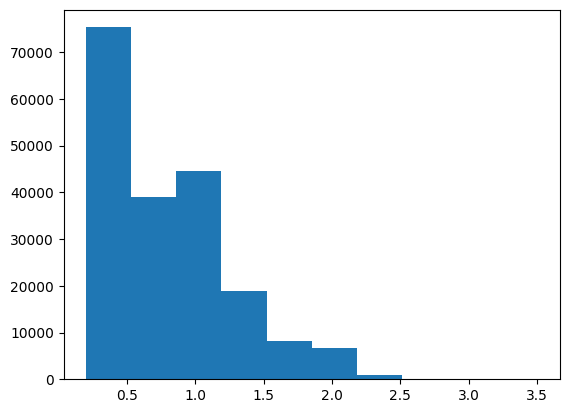

In [56]:
plt.hist(df["carat"])
plt.show()